In [ ]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 129.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import pandas as pd
import wfdb
import numpy as np
import os
from tqdm import tqdm
import concurrent.futures
import kagglehub

# Descargar dataset
local_path = kagglehub.dataset_download("khyeh0719/ptb-xl-dataset")
print("Dataset descargado en:", local_path)

# Detectar carpeta interna automáticamente
subfolders = os.listdir(local_path)
base_folder = os.path.join(local_path, subfolders[0])
print("BASE real:", base_folder)

BASE = base_folder
CSV_PATH = os.path.join(BASE, "ptbxl_database.csv")

# ===========================================================
# 1) CARGA CSV + LIMPIEZA DE EDAD NaN + META CORRECTA
# ===========================================================
df = pd.read_csv(CSV_PATH)


# 🔥 Filtrar filas con edad NaN
df = df.dropna(subset=["age"]).reset_index(drop=True)

# Edades
ages = df["age"].astype("float32").to_numpy()

# Sexo ya viene codificado: 0=female, 1=male
sex_bin = df["sex"].astype("float32").to_numpy()
meta_arr_full = sex_bin[:, None]   # shape (N,1)

# Paths WFDB completos
file_paths = df["filename_hr"].apply(lambda p: os.path.join(BASE, p)).tolist()

print("Registros:", len(df))
print("Ejemplo path:", file_paths[0])
print("Ages NaN count:", np.isnan(ages).sum())
print("Meta hombres:", meta_arr_full.sum())

# ===========================================================
# 2) CARGA PARALELA GARANTIZANDO ORDEN CORRECTO
# ===========================================================

def load_indexed(idx_path):
    i, path = idx_path
    sig, _ = wfdb.rdsamp(path)
    return i, sig.astype("float32")

N = len(file_paths)
X = np.zeros((N, 5000, 12), dtype="float32")

print("Cargando señales WFDB garantizando el orden correcto...")

with concurrent.futures.ThreadPoolExecutor(max_workers=16) as ex:
    for i, sig in tqdm(ex.map(load_indexed, enumerate(file_paths)), total=N):
        X[i] = sig

# ===========================================================
# 3) GUARDADO FINAL
# ===========================================================

np.save("data_500Hz.npy", X)
np.save("ages.npy", ages)
np.save("meta.npy", meta_arr_full)

print("✔ Señales alineadas y guardadas")
print("✔ data_500Hz shape:", X.shape)
print("✔ ages shape:", ages.shape)
print("✔ meta shape :", meta_arr_full.shape)
print("✔ Ages NaN:", np.isnan(ages).sum())
print("✔ Meta hombres (should be >0):", meta_arr_full.sum())


100%|██████████| 1.72G/1.72G [00:09<00:00, 192MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/khyeh0719/ptb-xl-dataset/versions/1
BASE real: /root/.cache/kagglehub/datasets/khyeh0719/ptb-xl-dataset/versions/1/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
Registros: 21748
Ejemplo path: /root/.cache/kagglehub/datasets/khyeh0719/ptb-xl-dataset/versions/1/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records500/00000/00001_hr
Ages NaN count: 0
Meta hombres: 10387.0
Cargando señales WFDB garantizando el orden correcto...


100%|██████████| 21748/21748 [01:01<00:00, 355.81it/s]


✔ Señales alineadas y guardadas
✔ data_500Hz shape: (21748, 5000, 12)
✔ ages shape: (21748,)
✔ meta shape : (21748, 1)
✔ Ages NaN: 0
✔ Meta hombres (should be >0): 10387.0


(21748, 5000, 12) (21748,) (21748, 1)
Train: (15223, 5000, 12) (15223, 1) (15223,)
Val : (3262, 5000, 12) (3262, 1) (3262,)
Test: (3263, 5000, 12) (3263, 1) (3263,)


Model: "Optimal_ECG_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg (InputLayer)    │ (None, 5000, 12)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 5000, 64)  │      5,440 │ ecg[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1250, 64)  │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1250, 64)  │     28,736 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1250, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1250, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1250, 64)  │     28,736 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1250, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1250, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1250, 64)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 250, 64)   │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 250, 128)  │     57,472 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 250, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 250, 128)  │    114,816 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 250, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 250, 128)  │      8,320 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 250, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 250, 128)  │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 924,777 (3.53 MB)

 Trainable params: 924,009 (3.52 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 125s 149ms/step - loss: 0.9546 - mae: 0.7536 - val_loss: 0.5208 - val_mae: 0.5748 - learning_rate: 3.0000e-04
Epoch 2/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5346 - mae: 0.5698 - val_loss: 0.4463 - val_mae: 0.5274 - learning_rate: 3.0000e-04
Epoch 3/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4486 - mae: 0.5193 - val_loss: 0.4961 - val_mae: 0.5589 - learning_rate: 3.0000e-04
Epoch 4/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4085 - mae: 0.4993 - val_loss: 0.4344 - val_mae: 0.5217 - learning_rate: 3.0000e-04
Epoch 5/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3886 - mae: 0.4870 - val_loss: 0.3796 - val_mae: 0.4890 - learning_rate: 3.0000e-04
Epoch 6/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3702 - mae: 0.4711 - val_loss: 0.4127 - val_mae: 0.5061 - learning_rate: 3.0000e-04
Epoch 7/40
476/476 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.3315 - mae: 0.4454 - val_loss: 0.3949 - val_mae: 0.4

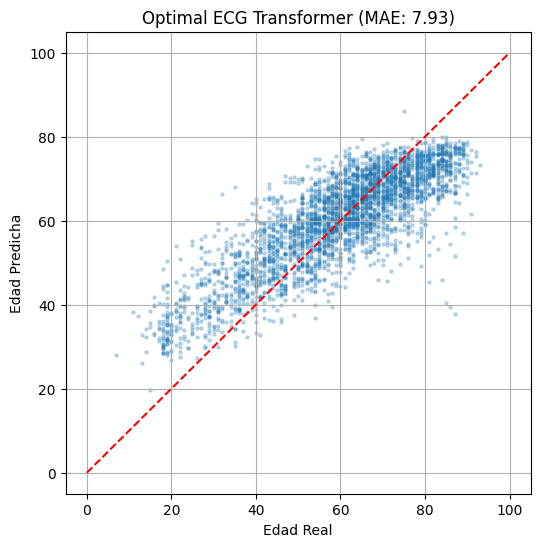

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ============================================
# 1) Cargar los NPY generados
# ============================================
X = np.load("data_500Hz.npy")      # (N, 5000, 12)
ages = np.load("ages.npy")         # (N,)
meta = np.load("meta.npy")         # (N,1)

print(X.shape, ages.shape, meta.shape)

# ============================================
# 2) Normalización (edad y metadata)
# ============================================
AGE_MEAN = ages.mean()
AGE_STD  = ages.std()

y_norm = (ages - AGE_MEAN) / AGE_STD
meta_norm = (meta - meta.mean()) / (meta.std() + 1e-6)

# ============================================
# 3) Train / Val / Test split
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_tmp, meta_train, meta_tmp, y_train, y_tmp = train_test_split(
    X, meta_norm, y_norm, test_size=0.30, random_state=42
)

X_val, X_test, meta_val, meta_test, y_val, y_test = train_test_split(
    X_tmp, meta_tmp, y_tmp, test_size=0.50, random_state=42
)

print("Train:", X_train.shape, meta_train.shape, y_train.shape)
print("Val :", X_val.shape, meta_val.shape, y_val.shape)
print("Test:", X_test.shape, meta_test.shape, y_test.shape)

# ============================================
# 4) Convertir a tf.data.Dataset
# ============================================
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_final = (
    tf.data.Dataset
    .from_tensor_slices(((X_train, meta_train), y_train))
    .shuffle(2000)
    .batch(BATCH)
    .prefetch(AUTOTUNE)
)

val_final = (
    tf.data.Dataset
    .from_tensor_slices(((X_val, meta_val), y_val))
    .batch(BATCH)
    .prefetch(AUTOTUNE)
)

test_final = (
    tf.data.Dataset
    .from_tensor_slices(((X_test, meta_test), y_test))
    .batch(BATCH)
)

# ============================================================
# (1) BLOQUE RESNET 1D
# ============================================================
def ResBlock(x, filters, kernel=7):
    shortcut = x

    x = layers.Conv1D(filters, kernel, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv1D(filters, kernel, padding="same")(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

# ============================================================
# (2) BLOQUE TRANSFORMER
# ============================================================
def TransformerBlock(x, num_heads=4, dff=256):
    dim = x.shape[-1]
    ln1 = layers.LayerNormalization()(x)
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=dim, dropout=0.1
    )(ln1, ln1)
    out1 = layers.Add()([x, attn_output])
    ln2 = layers.LayerNormalization()(out1)
    ffn = layers.Dense(dff, activation="relu")(ln2)
    ffn = layers.Dense(dim)(ffn)
    out2 = layers.Add()([out1, ffn])
    return out2

# ============================================================
# (3) MODELO COMPLETO
# ============================================================
def build_optimal_model(seq_len=5000, meta_dim=None):
    ecg_input = layers.Input(shape=(seq_len, 12), name="ecg")

    x = layers.Conv1D(64, 7, padding="same", activation="relu")(ecg_input)
    x = layers.MaxPooling1D(4)(x)

    x = ResBlock(x, 64)
    x = layers.MaxPooling1D(5)(x)

    x = ResBlock(x, 128)
    x = layers.MaxPooling1D(2)(x)

    x = TransformerBlock(x, num_heads=4, dff=256)
    x = TransformerBlock(x, num_heads=4, dff=256)

    avg = layers.GlobalAveragePooling1D()(x)
    mx  = layers.GlobalMaxPooling1D()(x)
    features = layers.Concatenate()([avg, mx])

    if meta_dim is not None:
        meta_in = layers.Input(shape=(meta_dim,), name="meta")
        m = layers.Dense(16, activation="relu")(meta_in)
        m = layers.Dense(8, activation="relu")(m)
        features = layers.Concatenate()([features, m])
        inputs = [ecg_input, meta_in]
    else:
        inputs = ecg_input

    x = layers.Dense(64, activation="relu")(features)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation="relu")(x)
    output = layers.Dense(1)(x)

    return models.Model(inputs, output, name="Optimal_ECG_Transformer")

model = build_optimal_model(seq_len=5000, meta_dim=1)
model.summary()

# ============================================================
# 10. ENTRENAMIENTO
# ============================================================
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4,
    global_clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        min_lr=1e-5
    )
]

history = model.fit(
    train_final,
    validation_data=val_final,
    epochs=40,
    callbacks=callbacks
)

# ============================================================
# 11. EVALUACIÓN FINAL
# ============================================================
X_ecg_list = []
X_meta_list = []
y_list = []

for (ecg, meta), y in test_final.unbatch():
    X_ecg_list.append(ecg.numpy())
    X_meta_list.append(meta.numpy())
    y_list.append(y.numpy())

X_ecg  = np.stack(X_ecg_list, axis=0).astype("float32")
X_meta = np.stack(X_meta_list, axis=0).astype("float32")
y_true_norm = np.array(y_list).astype("float32").flatten()

y_pred_norm = model.predict([X_ecg, X_meta], verbose=1).flatten()

y_pred = y_pred_norm * AGE_STD + AGE_MEAN
y_true = y_true_norm * AGE_STD + AGE_MEAN

mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("\nRESULTADOS:")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.25, s=5)
plt.plot([0, 100], [0, 100], 'r--')
plt.xlabel("Edad Real")
plt.ylabel("Edad Predicha")
plt.title(f"Optimal ECG Transformer (MAE: {mae:.2f})")
plt.grid(True)
plt.show()


102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MAE: 7.654916763305664
R2: 0.6739822030067444


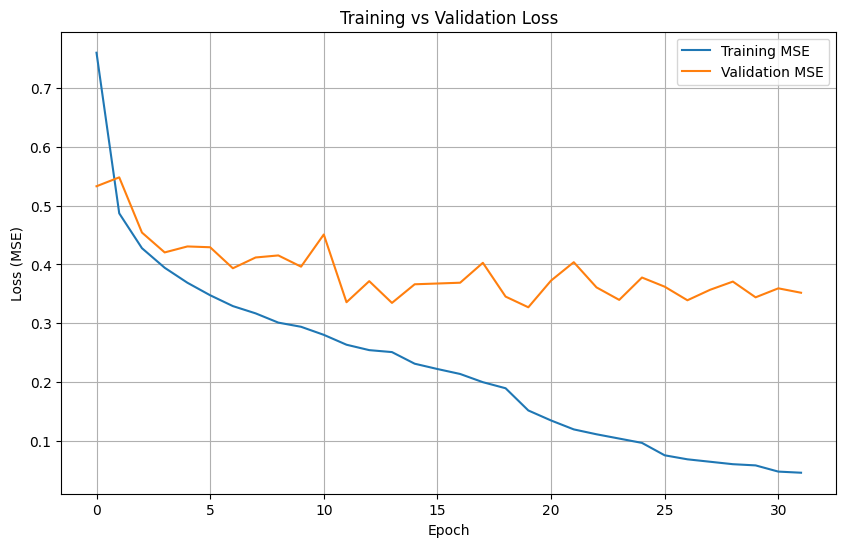

In [ ]:
# 1) Predicción normalizada (salida del modelo)
y_pred_norm = model.predict([X_test, meta_test]).flatten()

# 2) Desnormalización
y_pred = y_pred_norm * AGE_STD + AGE_MEAN
y_true = y_test * AGE_STD + AGE_MEAN

# 3) Métricas
print("MAE:", mean_absolute_error(y_true, y_pred))
print("R2:", r2_score(y_true, y_pred))

# 4) Gráfica de pérdidas
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


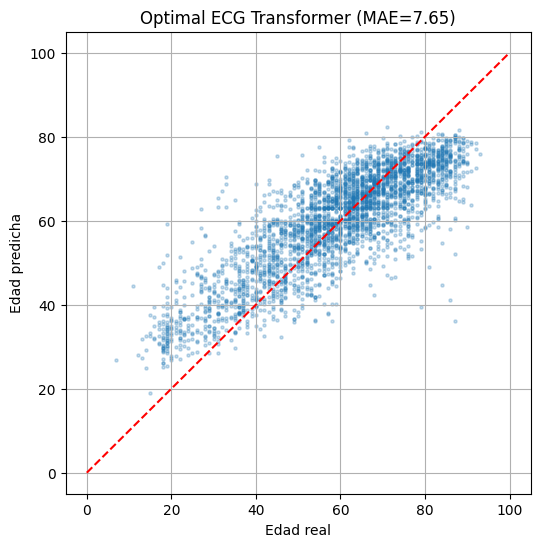

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.25, s=5)
plt.plot([0,100],[0,100],'r--')
plt.xlabel("Edad real")
plt.ylabel("Edad predicha")
plt.title(f"Optimal ECG Transformer (MAE={mean_absolute_error(y_true,y_pred):.2f})")
plt.grid(True)
plt.show()


1) Ruta base correcta

2) Cargar metadata (edad + sexo + filename_hr)

3) Conversión paralela WFDB → NumPy (5000×12)

4) Guardar metadata

Using Colab cache for faster access to the 'ptb-xl-dataset' dataset.
Dataset descargado en: /kaggle/input/ptb-xl-dataset
BASE real: /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
Registros: 21748
Ejemplo path: /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records500/00000/00001_hr
Ages NaN count: 0
Meta hombres: 10387.0
Cargando señales WFDB garantizando el orden correcto...


100%|██████████| 21748/21748 [01:02<00:00, 347.20it/s]


✔ Señales alineadas y guardadas
✔ data_500Hz shape: (21748, 5000, 12)
✔ ages shape: (21748,)
✔ meta shape : (21748, 1)
✔ Ages NaN: 0
✔ Meta hombres (should be >0): 10387.0


In [ ]:
print(df["sex"].value_counts(dropna=False))


sex
0    11379
1    10458
Name: count, dtype: int64


In [ ]:
np.save("ages.npy", ages)
np.save("meta.npy", meta_arr_full)

print("✔ Metadata guardada")


✔ Metadata guardada


Guardar el archivo final en Google Drive (para no perderlo)

No lo hicimos por ahora porque ocupa 5 GB

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/PTBXL_numpy"
os.makedirs(SAVE_DIR, exist_ok=True)

!cp data_500Hz.npy "$SAVE_DIR"/data_500Hz.npy


^C


In [ ]:
import os

file_path = "/content/data_500Hz.npy"
file_size_bytes = os.path.getsize(file_path)
file_size_mb = file_size_bytes / (1024 * 1024)

print(f"The file {file_path} weighs {file_size_mb:.2f} MB")

The file /content/data_500Hz.npy weighs 4998.09 MB


In [ ]:
!cp ages.npy "$SAVE_DIR"/ages.npy
!cp meta.npy "$SAVE_DIR"/meta.npy
